<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="images/upct_logo.png" alt="UPCT" style="height:145px; width:auto;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="images/umu_logo.png" alt="UMU" style="height:200px; width:auto;">
</div>

# Asignatura: **Deep Learning**

## Titulación: **Grado en Ciencia e Ingeniería de Datos**

## Práctica 4: Autocodificadores
### **Sesión 3/3: Autocodificadores variacionales**

**Autores**: Juan Morales Sánchez, Antonio Martínez Sánchez, José Luís Sancho Gómez y Juan Antonio Botía Blaya
___

### Objetivos

- Diseño de un *autoencoder* variacional.
- Comprender el aprendizaje probabilístico y las diferencias respecto a un *autoencoder* convencional
- Comprender el concepto de reparametrización y muestreo del espacio latente.
- Aplicación a la generación de imágenes.

### Contenidos
- [El dataset CelebA](#dataset)
- [*Autoencoder* variacional](#VAE)
- [Ejercicios](#ejercicios)

### Requisitos 
<a class='anchor' id='requisitos'></a>

- [Numpy](https://pypi.org/project/numpy/) (computación numérica)
- [Scipy](https://pypi.org/project/scipy/) (computación científica)
- [Scikit-learn](https://pypi.org/project/scikit-learn/) (*Machine Learning*)
- [Scikit-image](https://pypi.org/project/scikit-image/) (*Image Processing*)
- [Matplotlib](https://pypi.org/project/matplotlib/) y [Seaborn](https://pypi.org/project/seaborn/) (visualización de datos)
- [Tensorflow](https://www.tensorflow.org/) 2.x que incluye a [Keras](https://www.tensorflow.org/guide/keras) 2.x (*Deep Learning*)



<a class='anchor' id='dataset'></a>

## El dataset CelebA

En esta sesión de prácticas emplearemos también el dataset [50k Celeba Dataset 64x64](https://www.kaggle.com/datasets/therealcyberlord/50k-celeba-dataset-64x64).

<a class='anchor' id='VAE'></a>

## *Autoencoder* variacional

Un *autoencoder* variacional (VAE) es un tipo específico de *autoencoder* generativo. Mientras que un autoencoder clásico se centra en aprender una representación compacta (o codificación) para reconstruir la entrada, un autoencoder generativo, como el VAE, va un paso más allá: aprende una distribución probabilística en el espacio latente que permite generar nuevas muestras.

<div style="display:flex; justify-content:space-around; align-items:center; padding:5px solid #333333;">
    <img src="images/VAE.png" style="height:300px; width:auto">
</div>

Podemos resumir las principales diferencias de un VAE respecto a un *autoencoder* convencional en:

- **Aprendizaje probabilístico:**  
  En un VAE se modela la codificación como una distribución, habitualmente gaussiana de media $\mu$ y varianza $\sigma$, lo que permite tomar muestras de dicha distribución en el espacio latente $z$ y generar datos nuevos. Esto contrasta con un *autoencoder* tradicional, que produce una representación determinista.

- **Pérdida combinada:**  
  Los VAE añaden a la función de pérdida no solo el error de reconstrucción, sino también un término de divergencia KL (Kullback-Leibler) que regulariza la distribución latente $z$ para que se aproxime a la distribución de probabilidad predeterminada. Esto facilita la generación de muestras coherentes y continuas en el espacio latente.

- **Generación de nuevos datos:**  
  Mediante al muestreo en el espacio latente los VAE pueden generar nuevas datos que son similares a los datos de entrenamiento, convirtiéndolos en modelos generativos efectivos.

  A continuación se muestra un ejemplo de resultados de generación de imágenes de caras mediante VAE a partir del dataset [50k Celeba Dataset 64x64](https://www.kaggle.com/datasets/therealcyberlord/50k-celeba-dataset-64x64): 

<div style="display:flex; justify-content:space-around; align-items:center; padding:5px solid #333333;">
    <img src="images/generated_images.png" style="height:1000px; width:auto">
</div>

<a class='anchor' id='ejercicios'></a>

## Ejercicios

**E1:** Partiendo del trabajo de la sesión anterior, adapte un *autoencoder* convolucional de 3 niveles de profundidad, utilizando capas convolucionales 2D de 16, 32 y 64 mapas de características, más el nivel correspondiente al espacio latente (dimensión 64), para que se comporte como un *autoencoder* variacional. Para ello se debe atender a los aspectos puntualizados en el [apartado previo](#VAE) y [personalizar el modelo](https://www.tensorflow.org/guide/keras/making_new_layers_and_models_via_subclassing) para: 1) incorporar la reparametrización y muestro del espacio latente, forzando su estadística a una distribución normal (se requieren capas adicionales totalmente conectadas para enlazar con el nuevo espacio latente reparametrizado), y 2) implementación de la pérdida combinada (suma de la pérdida estándar del *autoencoder* con la pérdida de divergencia KL).




In [1]:
# Importar librerías necesarias
import os
import numpy as np
from tensorflow.keras.utils import get_file
from tensorflow.image import rgb_to_grayscale
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Descargar el dataset
dataset_url = "https://www.kaggle.com/api/v1/datasets/download/therealcyberlord/50k-celeba-dataset-64x64"

dataset_path = get_file(origin=dataset_url, extract=True)

base_dir = os.path.join(os.path.dirname(dataset_path), '50k-celeba-dataset-64x64', '50k')
try:
    os.listdir(base_dir)
except:
    base_dir = os.path.join(os.path.dirname(dataset_path), '50k')

print(f"Leyendo imágenes desde {base_dir:s}")

# Preparar listas para imágenes
NUMBER_OF_IMAGES = 10000 # <= 50000
IMAGE_DIM = (64, 64)

images = np.empty((NUMBER_OF_IMAGES, *IMAGE_DIM, 3))
images_gray = np.empty((NUMBER_OF_IMAGES, *IMAGE_DIM, 1))
for i, img_file in enumerate(os.listdir(base_dir)):
    if (i > 0) and (i%1000 == 0):
        print(f"Cargadas {i:d} imágenes...")
    if i == NUMBER_OF_IMAGES:
        break
    img_path = os.path.join(base_dir, img_file)
    img = load_img(img_path, target_size=IMAGE_DIM, color_mode='rgb')   # Redimensionar imágenes
    images[i] = img_to_array(img) / 255.0            # Normalizar a [0, 1]
    #images_gray[i] = rgb_to_grayscale(images[i])

Leyendo imágenes desde C:\Users\cgeal\.keras\datasets\50k-celeba-dataset-64x64\50k
Cargadas 1000 imágenes...
Cargadas 2000 imágenes...
Cargadas 3000 imágenes...
Cargadas 4000 imágenes...
Cargadas 5000 imágenes...
Cargadas 6000 imágenes...
Cargadas 7000 imágenes...
Cargadas 8000 imágenes...
Cargadas 9000 imágenes...
Cargadas 10000 imágenes...


In [2]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

x_train = images
IMAGE_SHAPE = x_train.shape[1:]
INPUT_DIM = int(np.prod(IMAGE_SHAPE))
ACTIVATION = keras.layers.LeakyReLU()
LATENT_DIM = 64
EPOCHS = 200
BATCH_SIZE = 256
KL_WEIGHT = 1.0

#Encoder
input = keras.layers.Input(shape=(IMAGE_SHAPE))

x = keras.layers.Conv2D(64//4, kernel_size=3, strides=2, padding='same')(input)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

x = keras.layers.Conv2D(64//2, kernel_size=3, strides=2, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

x = keras.layers.Conv2D(64, kernel_size=3, strides=2, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

x = keras.layers.SeparableConv2D(LATENT_DIM//64, kernel_size=3, activation='linear', padding='same')(x)
x = keras.layers.Flatten()(x)

z_mean = layers.Dense(LATENT_DIM, name='z_mean')(x)
z_log_var = layers.Dense(LATENT_DIM, name='z_log_var')(x)

def sampling(args):
	z_mean, z_log_var = args
	epsilon = K.random_normal(shape=K.shape(z_mean))
	return z_mean + K.exp(0.5 *z_log_var) * epsilon

z = layers.Lambda(sampling, name='z')([z_mean, z_log_var])
encoder = Model(input, [z_mean, z_log_var, z], name='encoder')

#Decoder
latent_input = keras.layers.Input(shape=(LATENT_DIM,))

x = keras.layers.Dense((IMAGE_SHAPE[0]//2**3 * IMAGE_SHAPE[1]//2**3 * LATENT_DIM//64))(latent_input)
x = keras.layers.Reshape((IMAGE_SHAPE[0]//2**3, IMAGE_SHAPE[1]//2**3, LATENT_DIM//64))(x)

x = keras.layers.Conv2DTranspose(64, kernel_size=3, strides=1, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

x = keras.layers.Conv2DTranspose(64//2, kernel_size=3, strides=2, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

x = keras.layers.Conv2DTranspose(32//2, kernel_size=3, strides=2, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.LeakyReLU()(x)

reconstructed = keras.layers.Conv2DTranspose(IMAGE_SHAPE[2], kernel_size=3, strides=2, padding='same', activation='sigmoid')(x)
decoder = Model(latent_input, reconstructed, name='decoder')

**E2:** Entrene el modelo con las imágenes de caras en color, y genere conjuntos de nuevas imágenes, similares a los mostrados en el [apartado previo](#VAE). Comente las diferencias en cuando a prestaciones con un *autoencoder* convolucional: calidad de la reconstrucción conseguida, número de parámetros necesarios en el modelo, tiempo de entrenamiento, etc. Tenga en cuenta que dado que el objetivo fundamental en este caso es generar imágenes y no reconstruirlas, los conjuntos de validación y test son prescindibles, y la parada anticipada puede realizarse directamente sobre el conjunto de entrenamiento (el sobreajuste puede mejorar la capacidad de generación de imágenes).



Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ ((None, 64), (None,    │        32,993 │
│                                 │ 64), (None, 64))       │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer (InputLayer)   │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d (Conv2D)            │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization        │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ leaky_re_lu_1 (LeakyReLU)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_1 (Conv2D)          │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_1      │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ leaky_re_lu_2 (LeakyReLU)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_2 (Conv2D)          │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_2      │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ leaky_re_lu_3 (LeakyReLU)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ separable_conv2d           │ (None, 8, 8, 1)        │           641 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ flatten (Flatten)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ z_mean (Dense)             │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ z_log_var (Dense)          │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ z (Lambda)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 64, 64, 3)      │        28,771 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer_1 (InputLayer) │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense (Dense)              │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ reshape (Reshape)          │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_transpose           │ (None, 8, 8, 64)       │           640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_3      │ (None, 8, 8, 64)       │           25

 Total params: 61,764 (241.27 KB)

 Trainable params: 61,316 (239.52 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - loss: 329.4578 - learning_rate: 0.0010
Epoch 2/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 286.9679 - learning_rate: 0.0010
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 200.4435 - learning_rate: 0.0010
Epoch 4/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 169.1902 - learning_rate: 0.0010
Epoch 5/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 156.6831 - learning_rate: 0.0010
Epoch 6/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 149.5699 - learning_rate: 0.0010
Epoch 7/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 145.3970 - learning_rate: 0.0010
Epoch 8/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 141.7310 - learning_rate: 0.0010
Epoch 9/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 139.3994 - learning_rate: 0.0010
Epoch 10/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 137.4523 - learning_rate: 0.0010
Epoch 11/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - loss: 

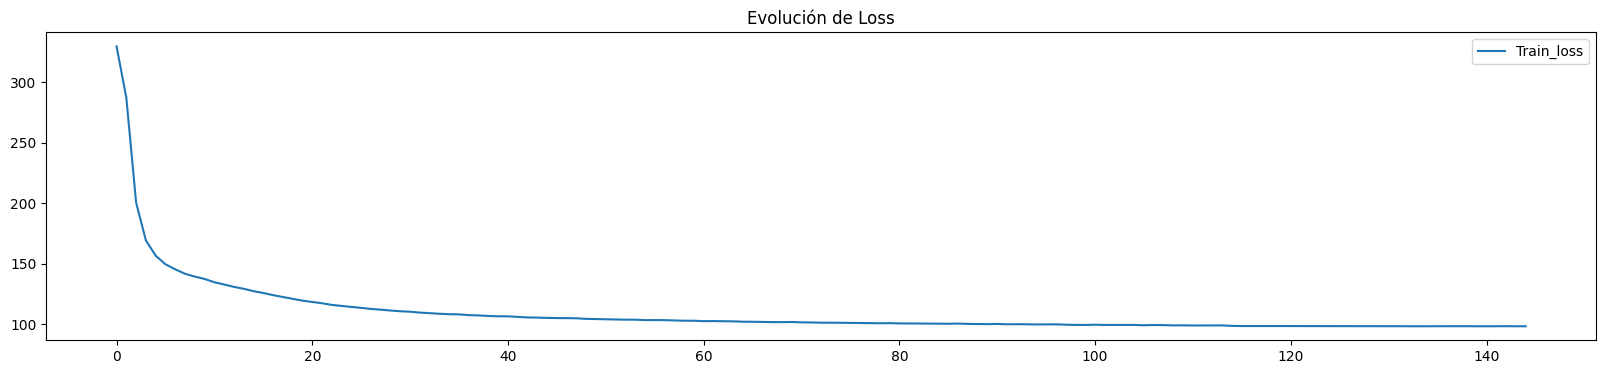

In [3]:
class VAE(Model):
	def __init__(self, encoder, decoder, kl_weight=1.0, **kwargs):
		super().__init__(**kwargs)
		self.encoder = encoder
		self.decoder = decoder
		self.kl_weight = K.variable(kl_weight, name='kl_weight')

	def call(self, inputs):
		z_mean, z_log_var, z = self.encoder(inputs)
		reconstructed = self.decoder(z)

		# Perdida de reconstruccion (MSE)
		reconstruction_loss = K.mean(K.square(inputs - reconstructed)) * IMAGE_SHAPE[0] * IMAGE_SHAPE[1]

		#Perdida KL
		kl_loss = -0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)

		#Agregar ambas perdidas
		total_loss = K.mean(reconstruction_loss + self.kl_weight * kl_loss)
		self.add_loss(total_loss)

		return reconstructed

#Definir el optimizador
optimizer = Adam(learning_rate=1e-3)

#Definir el callback de Early Stopping
early_stop = EarlyStopping(
	monitor='loss',
	patience=5,
	restore_best_weights=True
)

#Definir el callback ReduceLRONPLateau
reduce_lr = ReduceLROnPlateau(
	monitor='loss',
	patience=3,
	factor=0.1,
	min_lr=1e-6,
	verbose=1
)

vae = VAE(encoder, decoder, kl_weight=KL_WEIGHT)
vae.compile(optimizer=optimizer)
vae.build((None, ) + IMAGE_SHAPE)
vae.summary(expand_nested=True)

#Entrenamiento
history = vae.fit(
	x_train,
	epochs=EPOCHS,
	batch_size=BATCH_SIZE,
	callbacks=[early_stop, reduce_lr]
)

#Visualización de metricas
plt.figure(figsize=(20,4))
plt.plot(history.history['loss'], label='Train_loss')
plt.title('Evolución de Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


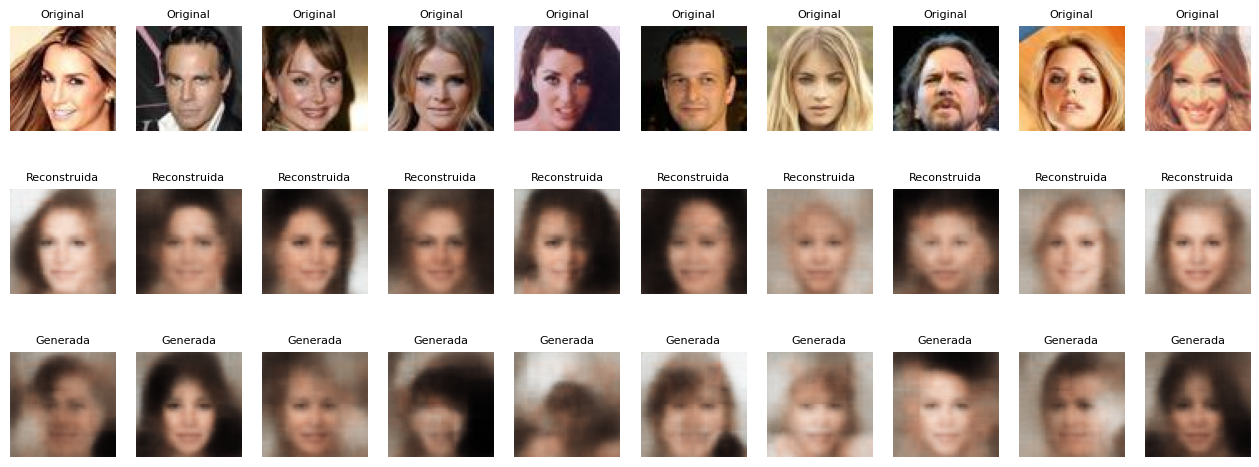

In [4]:
#Muestreo para generar nuevas imagenes
n = 10
z_sample = np.random.normal(size=(n, LATENT_DIM))
generated_images = decoder.predict(z_sample)

#Recontryuir imagenes
decoded_imgs = vae.predict(x_train)

#Visualizar imagenes´
fig, axes = plt.subplots(3, 10, figsize=(16, 6))
for i in range(10):
	axes[0, i].imshow(x_train[i], cmap='gray')
	axes[0, i].axis('off')
	axes[0, i].set_title(f"Original", fontsize=8)
	axes[1, i].imshow(decoded_imgs[i], cmap='gray')
	axes[1, i].axis('off')
	axes[1, i].set_title(f"Reconstruida", fontsize=8)
	axes[2, i].imshow(generated_images[i], cmap='gray')
	axes[2, i].axis('off')
	axes[2, i].set_title(f"Generada", fontsize=8)

**E3:** Evalúe la influencia sobre las prestaciones analizadas en el ejercicio E2 de:
- El aumento de la dimensión del espacio latente (máximo 1024).
- La ponderación de las pérdidas en la implementación de la suma de la pérdida combinada (desde 1 a 1, hasta un máximo de 10 a 1, orientativamente).



**E4:** Volviendo a la configuración del ejercicio E2. codifique todas las imágenes de entrenamiento en el espacio latente, y aplique a las codificaciones resultantes una reducción de dimensionalidad a 2 dimensiones con el [algoritmo PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), y compruebe mediante representación visual de dichas componentes si la estadística de dicho espacio se ajusta la predeterminada.



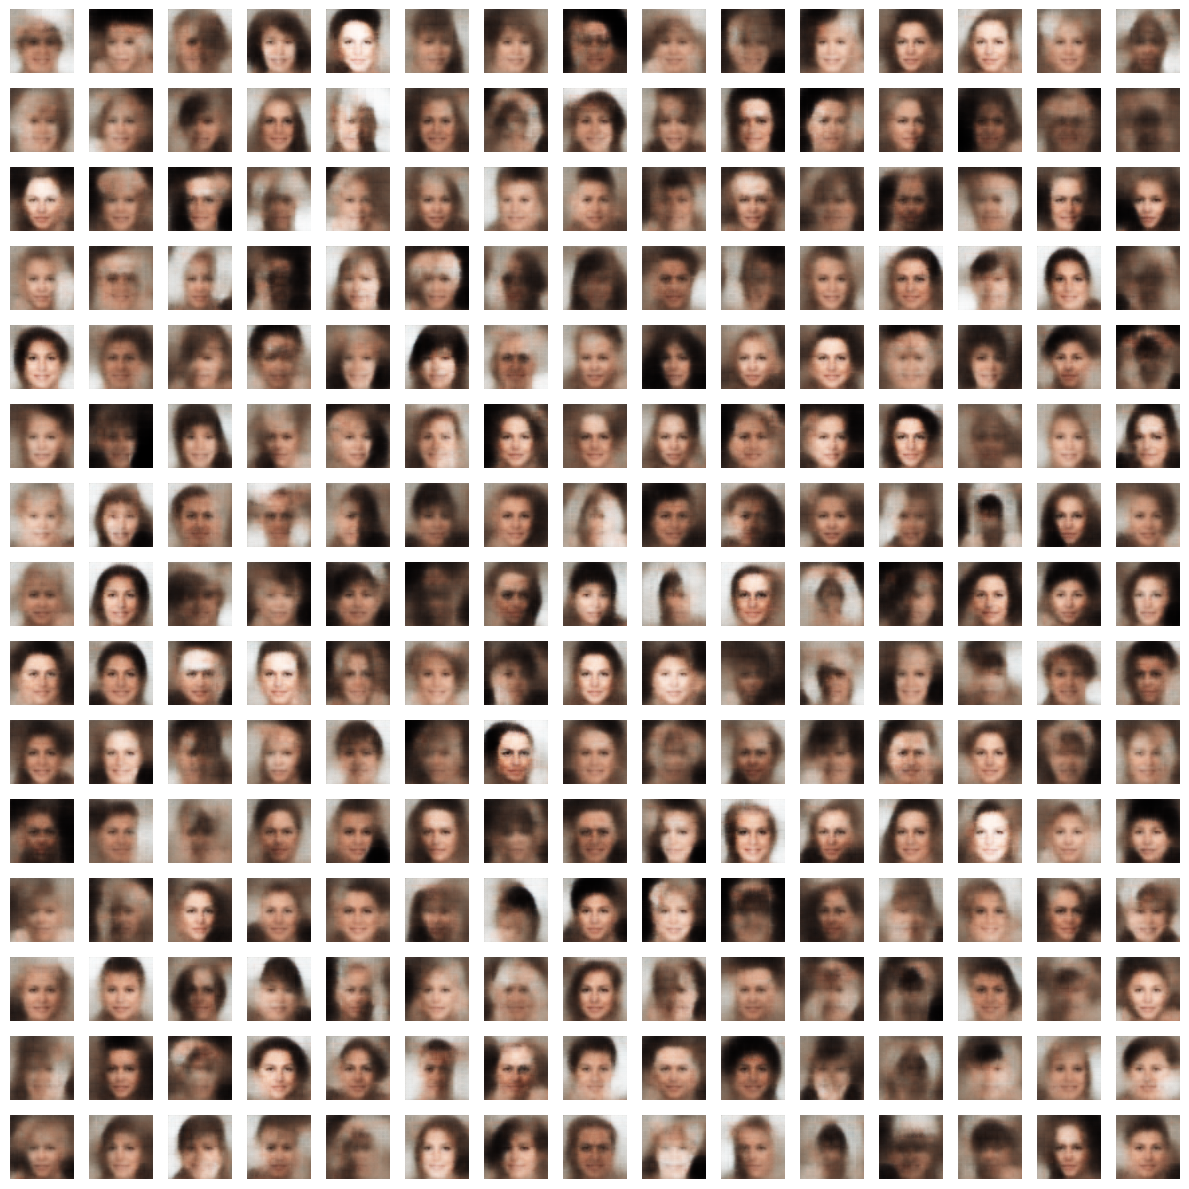

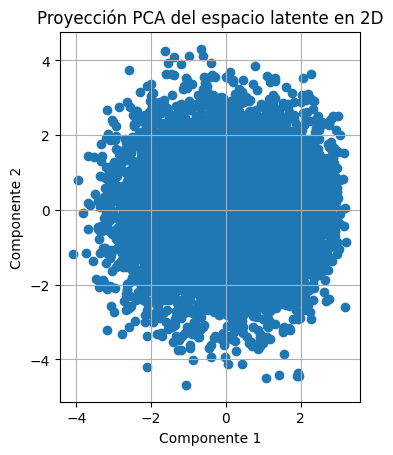

In [7]:
from sklearn.decomposition import PCA

# Generar muestras para cada punto del grid
plt.figure(figsize = (12,12))
for i in range(15):
	for j in range(15):
		z_sample = np.random.normal(size = (LATENT_DIM,))
		generated = decoder.predict(np.expand_dims(z_sample, axis = 0), verbose = 0)
		plt.subplot(15,15, i*15 + j + 1)
		plt.imshow(generated[0], cmap='gray')
		plt.axis('off')
plt.tight_layout()
plt.show()

# Proyectar a 2D
z = encoder.predict(x_train, verbose = 0)[2]
pca = PCA(n_components=2)
z_projected = pca.fit_transform(z)

plt.scatter(z_projected[:,0], z_projected[:,1])
plt.gca().set_aspect('equal')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('Proyección PCA del espacio latente en 2D')
plt.grid()
plt.show()

**E5:** Dadas las particularidades del conjunto de datos (imágenes de caras), resulta directo aplicar un aumento de datos trivial que duplique el tamaño del conjunto de entrenamiento, y que consiste en realizar un giro especular (horizontal) a cada una de las imágenes, y añadir dichas imágenes al conjunto inicial de entrenamiento. Implemente dicho aumento de datos y comente su influencia en la calidad de las imágenes generadas. En función de las posibilidades de cómputo, aumente también la cantidad de imágenes del conjunto de entrenamiento que se leen inicialmente del dataset [50k Celeba Dataset 64x64](https://www.kaggle.com/datasets/therealcyberlord/50k-celeba-dataset-64x64)

In [ ]:
# E5: Aumento de datos mediante giro especular horizontal
# Se duplica el conjunto de entrenamiento manteniendo las imagenes originales y sus versiones reflejadas.
x_train_flip = np.flip(x_train, axis=2)
x_train_aug = np.concatenate([x_train, x_train_flip], axis=0).astype('float32')

print(f'Tamano original del entrenamiento: {x_train.shape}')
print(f'Tamano tras aumento de datos:      {x_train_aug.shape}')

# Visualizar ejemplos originales y aumentados
n_examples = 8
fig, axes = plt.subplots(2, n_examples, figsize=(14, 4))
for i in range(n_examples):
    axes[0, i].imshow(x_train[i])
    axes[0, i].axis('off')
    axes[0, i].set_title('Original', fontsize=8)
    axes[1, i].imshow(x_train_flip[i])
    axes[1, i].axis('off')
    axes[1, i].set_title('Flip', fontsize=8)
plt.tight_layout()
plt.show()

# Para aumentar tambien la cantidad de imagenes iniciales del dataset, cambie NUMBER_OF_IMAGES
# en la primera celda de carga de datos y vuelva a ejecutar el notebook desde el principio.

def build_vae_model(latent_dim=LATENT_DIM, kl_weight=KL_WEIGHT):
    # Encoder con la misma configuracion del ejercicio E2
    encoder_input = keras.layers.Input(shape=IMAGE_SHAPE)

    x = keras.layers.Conv2D(16, kernel_size=3, strides=2, padding='same')(encoder_input)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU()(x)

    x = keras.layers.Conv2D(32, kernel_size=3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU()(x)

    x = keras.layers.Conv2D(64, kernel_size=3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU()(x)

    x = keras.layers.SeparableConv2D(max(latent_dim // 64, 1), kernel_size=3, activation='linear', padding='same')(x)
    x = keras.layers.Flatten()(x)

    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
    z = layers.Lambda(sampling, name='z')([z_mean, z_log_var])
    encoder_model = Model(encoder_input, [z_mean, z_log_var, z], name='encoder_aug')

    # Decoder simetrico
    latent_input = keras.layers.Input(shape=(latent_dim,))
    x = keras.layers.Dense((IMAGE_SHAPE[0] // 2**3) * (IMAGE_SHAPE[1] // 2**3) * max(latent_dim // 64, 1))(latent_input)
    x = keras.layers.Reshape((IMAGE_SHAPE[0] // 2**3, IMAGE_SHAPE[1] // 2**3, max(latent_dim // 64, 1)))(x)

    x = keras.layers.Conv2DTranspose(64, kernel_size=3, strides=1, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU()(x)

    x = keras.layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU()(x)

    x = keras.layers.Conv2DTranspose(16, kernel_size=3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU()(x)

    decoder_output = keras.layers.Conv2DTranspose(IMAGE_SHAPE[2], kernel_size=3, strides=2, padding='same', activation='sigmoid')(x)
    decoder_model = Model(latent_input, decoder_output, name='decoder_aug')

    vae_model = VAE(encoder_model, decoder_model, kl_weight=kl_weight)
    vae_model.compile(optimizer=Adam(learning_rate=1e-3))
    vae_model.build((None,) + IMAGE_SHAPE)
    return encoder_model, decoder_model, vae_model

encoder_aug, decoder_aug, vae_aug = build_vae_model()
vae_aug.summary(expand_nested=True)

# Callbacks nuevos para evitar reutilizar el estado de los callbacks del entrenamiento anterior
early_stop_aug = EarlyStopping(
    monitor='loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr_aug = ReduceLROnPlateau(
    monitor='loss',
    patience=3,
    factor=0.1,
    min_lr=1e-6,
    verbose=1
)

history_aug = vae_aug.fit(
    x_train_aug,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_aug, reduce_lr_aug]
)

plt.figure(figsize=(20, 4))
plt.plot(history.history['loss'], label='Sin aumento')
plt.plot(history_aug.history['loss'], label='Con aumento horizontal')
plt.title('Comparacion de la perdida de entrenamiento')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Comparacion visual: reconstrucciones y nuevas imagenes generadas
n = 10
z_sample = np.random.normal(size=(n, LATENT_DIM))
generated_aug = decoder_aug.predict(z_sample, verbose=0)
reconstructed_aug = vae_aug.predict(x_train[:n], verbose=0)

fig, axes = plt.subplots(3, n, figsize=(16, 6))
for i in range(n):
    axes[0, i].imshow(x_train[i])
    axes[0, i].axis('off')
    axes[0, i].set_title('Original', fontsize=8)

    axes[1, i].imshow(reconstructed_aug[i])
    axes[1, i].axis('off')
    axes[1, i].set_title('Reconstr.', fontsize=8)

    axes[2, i].imshow(generated_aug[i])
    axes[2, i].axis('off')
    axes[2, i].set_title('Generada', fontsize=8)
plt.tight_layout()
plt.show()

# Generacion en mosaico para valorar diversidad y simetria facial
plt.figure(figsize=(12, 12))
for i in range(15):
    for j in range(15):
        z_sample = np.random.normal(size=(1, LATENT_DIM))
        generated = decoder_aug.predict(z_sample, verbose=0)
        plt.subplot(15, 15, i * 15 + j + 1)
        plt.imshow(generated[0])
        plt.axis('off')
plt.tight_layout()
plt.show()

# Comentario orientativo para completar tras observar las figuras
print('Comentario E5: el aumento horizontal suele aportar mas variedad de poses/orientaciones y reduce sesgos izquierda-derecha.')
print('Como contrapartida, cada epoca tarda aproximadamente el doble al entrenar con el doble de imagenes.')
print('Compare visualmente nitidez, coherencia de ojos/boca/pelo y diversidad frente a las generaciones del modelo sin aumento.')

Gracias a las nuevas muestras hay algo más de claridad, más detalles por lo que se generan caras algo más diferentes, pero sigue habiendo fuerte generalización y similitudes entre las caras.